<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/Outlier_detection_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("/content/EmployeeAttrition.csv")
df.shape

(1470, 35)

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [ ]:
df.columns[df.nunique()==1]

Index(['EmployeeCount', 'Over18', 'StandardHours'], dtype='object')

In [ ]:
# EmployeeNumber
df.drop(columns = ['EmployeeCount', 'Over18',
                   'StandardHours','EmployeeNumber'],inplace=True)
df.shape

(1470, 31)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(1470, 31)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#X & Y

In [ ]:
X = df.drop(columns=['Attrition'])
Y = df['Attrition']
X.shape,Y.shape

((1470, 30), (1470,))

In [ ]:
X.dtypes

,0
Age,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object
HourlyRate,int64


In [ ]:
X['BusinessTravel'].unique()

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object)

In [ ]:
#label encoding --> BusinessTravel
label_map = {'BusinessTravel':{'Travel_Rarely':1,
                               'Travel_Frequently':2,
                               'Non-Travel':0}}
X.replace(label_map,inplace=True)

/tmp/ipykernel_2217/1425124707.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.replace(label_map,inplace=True)


In [ ]:
X['BusinessTravel'].unique()

array([1, 2, 0])

In [ ]:
X_ohe = pd.get_dummies(X)
X_ohe.shape

(1470, 49)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X_ohe,Y,
                                            test_size=0.3,
                                            random_state=7,
                                            stratify=Y)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((1029, 49), (441, 49), (1029,), (441,))

In [ ]:
#nunique < 15

cat_col = X_train.columns[X_train.nunique()<=15]
cat_col

Index(['BusinessTravel', 'Education', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_

In [ ]:
con_col = X_train.columns[X_train.nunique()>15]
con_col

Index(['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
       'MonthlyRate', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

# Outlier Detection

- Zscore

- IQR

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_sc = sc.transform(X_train)
X_test_sc = sc.transform(X_test)

## Detect outliers based on Zscore

In [ ]:
def outlier_detection_zc(df,col):
  print("Outliers in column->", col)
  o_count = df.loc[(df[col]<-3)|(df[col]>3),col].shape[0]
  print(o_count)

In [ ]:
X_train_sc = pd.DataFrame(X_train_sc,
                          columns=X_train.columns)
for col in con_col:
  outlier_detection_zc(X_train_sc,col)

Outliers in column-> Age
0
Outliers in column-> DailyRate
0
Outliers in column-> DistanceFromHome
0
Outliers in column-> HourlyRate
0
Outliers in column-> MonthlyIncome
0
Outliers in column-> MonthlyRate
0
Outliers in column-> TotalWorkingYears
14
Outliers in column-> YearsAtCompany
19
Outliers in column-> YearsInCurrentRole
11
Outliers in column-> YearsSinceLastPromotion
26
Outliers in column-> YearsWithCurrManager
8


# Outlier detection using iqr

In [ ]:
def outlier_detection_iqr(df,col):
  q1,q3 = df[col].quantile([0.25,0.75])
  iqr = q3-q1
  LB = q1 - 1.5*iqr
  UB = q3 + 1.5*iqr
  print("Outliers in column->", col)
  o_count = df.loc[(df[col] < LB) | (df[col]>UB),col].shape[0]
  print(o_count)

In [ ]:
for col in con_col:
  outlier_detection_iqr(X_train,col)

Outliers in column-> Age
0
Outliers in column-> DailyRate
0
Outliers in column-> DistanceFromHome
0
Outliers in column-> HourlyRate
0
Outliers in column-> MonthlyIncome
69
Outliers in column-> MonthlyRate
0
Outliers in column-> TotalWorkingYears
45
Outliers in column-> YearsAtCompany
69
Outliers in column-> YearsInCurrentRole
11
Outliers in column-> YearsSinceLastPromotion
73
Outliers in column-> YearsWithCurrManager
8


# Outlier Removal using Zscore

In [ ]:
def outlier_removal_zc(df,col):
  df1 = df.copy()
  print("Column -->",col)
  print("Rows before removing outliers",df1.shape[0])
  df1 = df1.loc[(df1[col]>=-3)&(df1[col]<=3),:]
  print("Rows after removing outliers",df1.shape[0])
  return df1

In [ ]:
X_train_sc_or = X_train_sc.copy()
for col in con_col:
  X_train_sc_or = outlier_removal_zc(X_train_sc_or,col)

Column --> Age
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> DailyRate
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> DistanceFromHome
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> HourlyRate
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> MonthlyIncome
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> MonthlyRate
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> TotalWorkingYears
Rows before removing outliers 1029
Rows after removing outliers 1015
Column --> YearsAtCompany
Rows before removing outliers 1015
Rows after removing outliers 1000
Column --> YearsInCurrentRole
Rows before removing outliers 1000
Rows after removing outliers 992
Column --> YearsSinceLastPromotion
Rows before removing outliers 992
Rows after removing outliers 976
Column --> YearsWithCurrManager
Rows before removing outlie

# Outlier Removal using IQR

In [ ]:
def outlier_removal_iqr(df,col):
  df1 = df.copy()
  q1,q3 = df1[col].quantile([0.25,0.75])
  iqr = q3-q1
  LB = q1 - 1.5*iqr
  UB = q3 + 1.5*iqr
  print("Column -->",col)
  print("Rows before removing outliers",df1.shape[0])
  df1 = df1.loc[(df1[col]>=LB)&(df1[col]<=UB),:]
  print("Rows after removing outliers",df1.shape[0])
  return df1

In [ ]:
X_train_or = X_train.copy()
for col in con_col:
  X_train_or = outlier_removal_iqr(X_train_or,col)

Column --> Age
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> DailyRate
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> DistanceFromHome
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> HourlyRate
Rows before removing outliers 1029
Rows after removing outliers 1029
Column --> MonthlyIncome
Rows before removing outliers 1029
Rows after removing outliers 960
Column --> MonthlyRate
Rows before removing outliers 960
Rows after removing outliers 960
Column --> TotalWorkingYears
Rows before removing outliers 960
Rows after removing outliers 912
Column --> YearsAtCompany
Rows before removing outliers 912
Rows after removing outliers 895
Column --> YearsInCurrentRole
Rows before removing outliers 895
Rows after removing outliers 893
Column --> YearsSinceLastPromotion
Rows before removing outliers 893
Rows after removing outliers 793
Column --> YearsWithCurrManager
Rows before removing outliers 793
R

# Outlier Imputation

In [ ]:
def outlier_impute_zc(df,col):
  df1 = df.copy()
  print("Column -->",col)
  df1.loc[(df1[col]<-3),col] = -3
  df1.loc[(df1[col]>3),col] = 3
  print(df1[col].min(), df1[col].max())
  return df1

In [ ]:
X_train_sc_io = X_train_sc.copy()
for col in con_col:
  X_train_sc_io = outlier_impute_zc(X_train_sc_io,col)

Column --> Age
-2.0460451710081347 2.529447957452466
Column --> DailyRate
-1.7174708636889437 1.7349192671167921
Column --> DistanceFromHome
-0.997432893693513 2.5308711619353996
Column --> HourlyRate
-1.778655035046836 1.6591457585352494
Column --> MonthlyIncome
-1.1619324653374639 2.9272683827988875
Column --> MonthlyRate
-1.7231722576056423 1.771638064367085
Column --> TotalWorkingYears
-1.4235994340147937 3.0
Column --> YearsAtCompany
-1.1539443619793066 3.0
Column --> YearsInCurrentRole
-1.195567661761814 3.0
Column --> YearsSinceLastPromotion
-0.676713965401559 3.0
Column --> YearsWithCurrManager
-1.1714142612068223 3.0


In [ ]:
def outlier_imputation_iqr(df,col):
  df1 = df.copy()
  q1,q3 = df1[col].quantile([0.25,0.75])
  iqr = q3-q1
  LB = q1 - 1.5*iqr
  UB = q3 + 1.5*iqr
  print("Column -->",col)
  df1.loc[(df1[col]<LB),col] = LB
  df1.loc[(df1[col]>UB),col] = UB
  print(LB,UB, df1[col].min(),df1[col].max())
  return df1

In [ ]:
X_train_io = X_train.copy()
for col in con_col:
  X_train_io = outlier_imputation_iqr(X_train_io,col)

Column --> Age
-2.863097515376099 2.801798738908454 -2.0460451710081347 2.529447957452466
Column --> DailyRate
-3.4139892230963476 3.4907910385151255 -1.7174708636889437 1.7349192671167921
Column --> DistanceFromHome
-2.9506012102023753 2.5938765915002016 -0.997432893693513 2.5308711619353996
Column --> HourlyRate
-3.5466668717461944 3.5253804750512385 -1.778655035046836 1.6591457585352494
Column --> MonthlyIncome
-2.574630174500368 2.2287361033463613 -1.1619324653374639 2.2287361033463613
Column --> MonthlyRate
-3.4339524238505934 3.4178684314509256 -1.7231722576056423 1.771638064367085
Column --> TotalWorkingYears
-2.3825440645471474 2.2203901620081488 -1.4235994340147937 2.2203901620081488
Column --> YearsAtCompany
-2.1588036695759554 1.8606335608106397 -1.1539443619793066 1.8606335608106397
Column --> YearsInCurrentRole
-2.769129331934137 2.9529131050561275 -1.195567661761814 2.9529131050561275
Column --> YearsSinceLastPromotion
-2.099749395370641 1.6950117512135783 -0.676713965401

# Apply PCA

In [ ]:
X_test.mean()

,0
Age,37.256236
BusinessTravel,1.049887
DailyRate,814.183673
DistanceFromHome,9.839002
Education,2.893424
EnvironmentSatisfaction,2.705215
HourlyRate,65.131519
JobInvolvement,2.755102
JobLevel,2.117914
JobSatisfaction,2.750567


In [ ]:
# PAss the training data w/o SC
from sklearn.decomposition import PCA
pca = PCA(random_state=7) #generate all possible components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

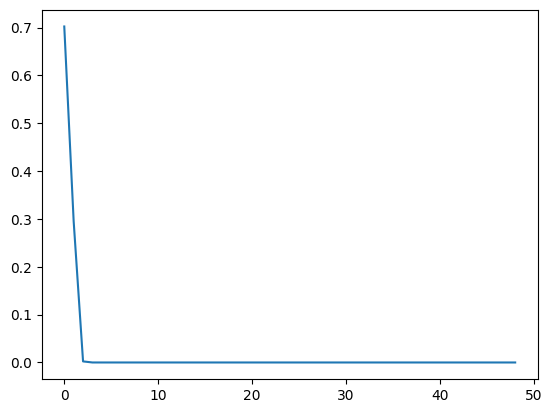

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)), pca.explained_variance_ratio_)